In [5]:
import pandas as pd

# 01 CFPB Stratified Sampling and Feature Preparation

Objective: construct a reproducible, proportionally stratified CFPB sample that preserves Product x Year-Quarter x Region structure for downstream EDA and forecasting notebooks.

This notebook prepares the following artifacts:
- engineered temporal and geographic features (`year_quarter`, `region`, `stratum`)
- exploratory state-level and final region-level stratification diagnostics
- final 300k stratified sample exported for exploratory data analysis (notebook 02)

In [4]:
# Load the CFPB complaints CSV into a DataFrame
df = pd.read_csv(r'..\data\complaints.csv')

In [6]:
# Preview the dataset structure and sample records
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-13,Mortgage,FHA mortgage,Trouble during payment process,NaN,"I currently have my mortgage with GMFS, servic...",NaN,"SAMC Honebee TRS, LLC",AL,36695,NaN,Consent provided,Web,2020-07-13,Closed with explanation,Yes,NaN,3743391
1,2023-12-16,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"FactorTrust, Inc.",NY,13224,NaN,Consent not provided,Web,2023-12-16,Closed with explanation,Yes,NaN,8011171
2,2024-01-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,11714,NaN,Consent not provided,Web,2024-01-27,Closed with non-monetary relief,Yes,NaN,8236394
3,2019-05-22,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with fraud alerts or security freezes,NaN,Have had a couple years of problems getting an...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,CA,95628,Older American,Consent provided,Web,2019-05-22,Closed with explanation,Yes,NaN,3251015
4,2023-12-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Personal information incorrect,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32703,NaN,Consent not provided,Web,2023-12-21,Closed with explanation,Yes,NaN,8032795


In [7]:
# Check total row count in the raw dataset
print(f"{len(df):,}")

13,843,560


In [8]:
# Inspect complaint volume by product
df['Product'].value_counts().reset_index(name='num_instances')

,Product,num_instances
0,Credit reporting or other personal consumer re...,8648731
1,"Credit reporting, credit repair services, or o...",2163844
2,Debt collection,1013429
3,Mortgage,440724
4,Checking or savings account,344990
5,Credit card,290278
6,Credit card or prepaid card,206368
7,"Money transfer, virtual currency, or money ser...",169517
8,Credit reporting,140429
9,Student loan,121694


In [9]:
# Inspect complaint volume by sub-product
df['Sub-product'].value_counts().reset_index(name='num_instances')

,Sub-product,num_instances
0,Credit reporting,10755952
1,I do not know,372881
2,General-purpose credit card or charge card,338623
3,Checking account,337944
4,Other debt,181044
...,...,...
81,Traveler’s/Cashier’s checks,88
82,Student prepaid card,55
83,Tax refund anticipation loan or check,42
84,Transit card,37


In [10]:
# Verify min/max complaint received dates
print(f"Dates range from {min(df['Date received'])} to {max(df['Date received'])}")

Dates range from 2011-12-01 to 2026-02-24


## Step 1: Creating Year-Quarter

In [11]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

df['year_quarter'] = (
    df['Date received']
      .dt.to_period('Q')
      .astype(str)
)

This gives values like '2021Q1', '2022Q3', etc.

## Step 2: Define Initial Geography Field

Before moving to regional aggregation, a state-level geography field is created to support exploratory strata design and sparsity checks.

In [12]:
df['geo'] = df['State']

## Step 3: Mapping State to Region

For the final workflow, I use U.S. Census Bureau regions instead of individual states. This reduces sparsity while still preserving meaningful geographic structure for the downstream sample.

**1. Northeast**
- CT, ME, MA, NH, RI, VT
- NJ, NY, PA

**2. Midwest**
- IL, IN, MI, OH, WI
- IA, KS, MN, MO, NE, ND, SD

**3. South**
- DE, FL, GA, MD, NC, SC, VA, DC, WV
- AL, KY, MS, TN
- AR, LA, OK, TX

**4. West**
- AZ, CO, ID, MT, NV, NM, UT, WY
- AK, CA, HI, OR, WA

**5. Other**
- Any remaining values in State (e.g., territories or non-state codes)

In [13]:
northeast = ['CT','ME','MA','NH','RI','VT','NJ','NY','PA']
midwest   = ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD']
south     = ['DE','FL','GA','MD','NC','SC','VA','DC','WV',
             'AL','KY','MS','TN','AR','LA','OK','TX']
west      = ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA']

def map_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'

df['region'] = df['State'].apply(map_region)

Rows with unresolved geography are removed so each record can be assigned to a valid regional stratum in later steps.

In [14]:
# Drop rows without valid region
df = df.dropna(subset=['region'])

Regional share is reviewed here to confirm that the aggregated geography feature is coherent and suitable for proportional sampling.

In [15]:
df['region'].value_counts(normalize=True)

region
South        0.540400
West         0.161662
Northeast    0.158621
Midwest      0.130691
Other        0.008627
Name: proportion, dtype: float64

## Step 4: Finalize Geography for Production Strata

The region field is adopted as the production geography feature to balance interpretability and stratum stability.

In [16]:
df['year_quarter'] = pd.to_datetime(df['Date received']).dt.to_period('Q').astype(str)

df['stratum'] = (
    df['Product'].astype(str) + "|" +
    df['year_quarter'].astype(str) + "|" +
    df['region'].astype(str)
)

## Step 5: Sanity Check Stratum Granularity

A quick cardinality check ensures strata are neither too coarse (loss of structure) nor too sparse (unstable sampling allocations).

In [17]:
num_unique_strata = df['stratum'].nunique()
print(f"Total number of unique strata: {num_unique_strata:,}")

Total number of unique strata: 2,752


In [18]:
strata_counts = df.groupby(['Product', 'year_quarter', 'region']).size()

strata_counts.describe()

count      2752.000000
mean       5030.363372
std       35783.133537
min           1.000000
25%         142.750000
50%         539.000000
75%        1692.250000
max      917786.000000
dtype: float64

Interpretation:
- The median stratum size is sufficiently large for stable proportional sampling.
- The distribution remains right-skewed, which is expected in CFPB data (heavy concentration in specific product-time-region combinations).
- A small long-tail of low-count strata is acceptable when the share of sparse strata is minimal.

In [19]:
print(f"Number of strata with fewer than 20 samples: {(strata_counts < 20).sum():,} out of {num_unique_strata:,} (i.e., {((strata_counts < 20).sum()/num_unique_strata):.1}%).")

Number of strata with fewer than 20 samples: 194 out of 2,752 (i.e., 0.07%).


Conclusion from diagnostics: the current stratum design is appropriate for sampling, with manageable sparsity and strong representational coverage.

In [20]:
# Generate total number of complaints for each quarter
quarterly_complaints = df.groupby('year_quarter').size().reset_index(name='num_complaints')
quarterly_complaints

,year_quarter,num_complaints
0,2011Q4,2536
1,2012Q1,12969
2,2012Q2,21160
3,2012Q3,19125
4,2012Q4,19118
5,2013Q1,26874
6,2013Q2,24837
7,2013Q3,28471
8,2013Q4,28033
9,2014Q1,39607


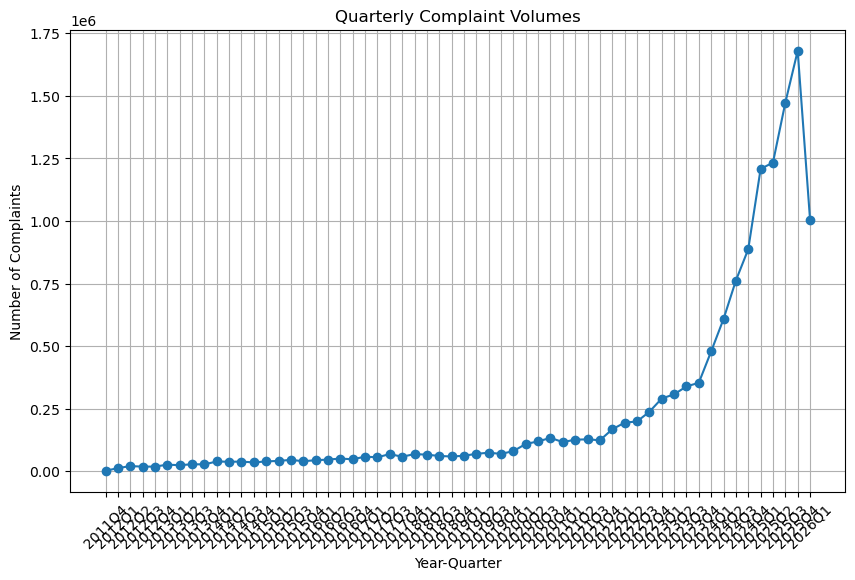

In [21]:
# Plot the quarterly complaint volumes
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(quarterly_complaints['year_quarter'], quarterly_complaints['num_complaints'], marker='o')
plt.title('Quarterly Complaint Volumes')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [24]:
# Plot the distribution of complaints by product per quarter
product_counts_qtr = df.groupby(['year_quarter', 'Product']).size().reset_index(name='num_complaints')

In [31]:
# Tabulate the complaint counts by product and quarter (year_quarter in col. 1, and then each product takes a column each)
product_counts_pivot = product_counts_qtr.pivot(index='year_quarter', columns='Product', values='num_complaints').fillna(0)
product_counts_pivot

Product,Bank account or service,Checking or savings account,Consumer Loan,Credit card,Credit card or prepaid card,Credit reporting,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Debt or credit management,...,Money transfers,Mortgage,Other financial service,Payday loan,"Payday loan, title loan, or personal loan","Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease,Virtual currency
year_quarter,,,,,,,,,,,,,,,,,,,,,
2011Q4,0.0,0.0,0.0,1260.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1276.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012Q1,1191.0,0.0,141.0,3757.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7356.0,0.0,0.0,0.0,0.0,0.0,524.0,0.0,0.0
2012Q2,4318.0,0.0,650.0,4340.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10860.0,0.0,0.0,0.0,0.0,0.0,992.0,0.0,0.0
2012Q3,3643.0,0.0,591.0,3780.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10465.0,0.0,0.0,0.0,0.0,0.0,646.0,0.0,0.0
2012Q4,3060.0,0.0,604.0,3476.0,0.0,1873.0,0.0,0.0,0.0,0.0,...,0.0,9427.0,0.0,0.0,0.0,0.0,0.0,678.0,0.0,0.0
2013Q1,3532.0,0.0,698.0,3584.0,0.0,3074.0,0.0,0.0,0.0,0.0,...,0.0,15247.0,0.0,0.0,0.0,0.0,0.0,739.0,0.0,0.0
2013Q2,3077.0,0.0,771.0,3310.0,0.0,3470.0,0.0,0.0,0.0,0.0,...,128.0,13459.0,0.0,0.0,0.0,0.0,0.0,622.0,0.0,0.0
2013Q3,3428.0,0.0,815.0,3197.0,0.0,3949.0,0.0,0.0,4397.0,0.0,...,167.0,11756.0,0.0,0.0,0.0,0.0,0.0,762.0,0.0,0.0
2013Q4,3351.0,0.0,833.0,3014.0,0.0,3887.0,0.0,0.0,6672.0,0.0,...,264.0,8936.0,0.0,194.0,0.0,0.0,0.0,882.0,0.0,0.0


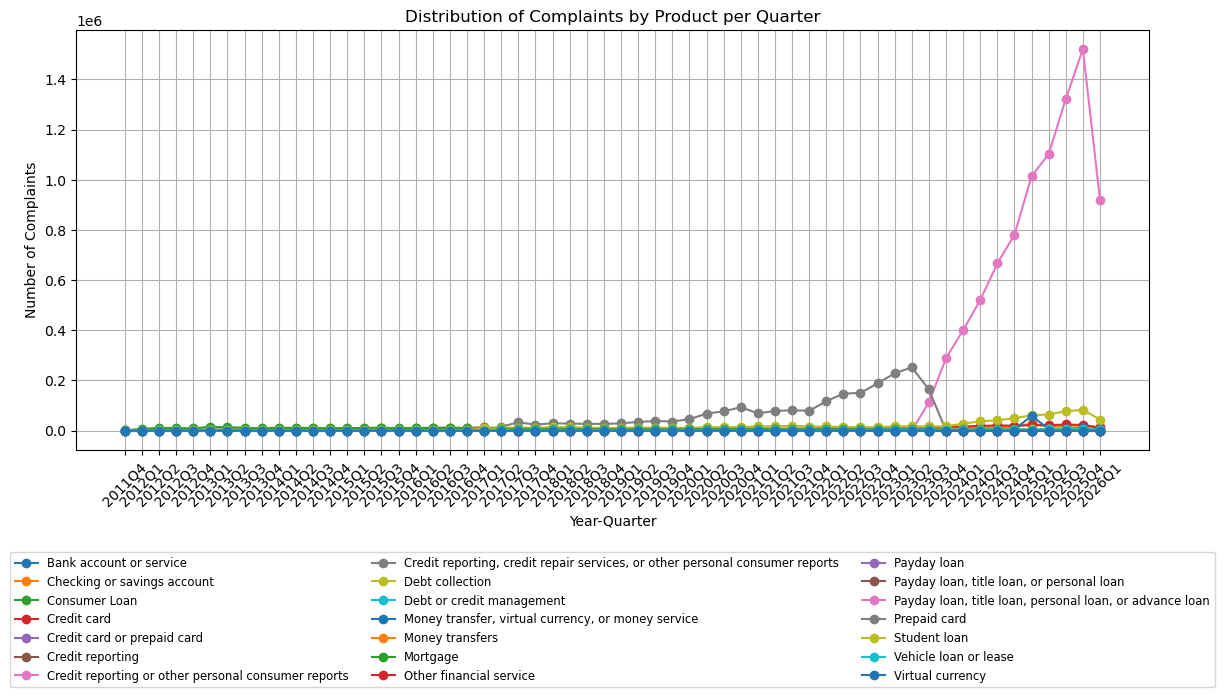

In [32]:
# Plot a line chart for each product's complaint volume over time
plot_df = product_counts_qtr.copy()
plot_df['year_q_period'] = pd.PeriodIndex(plot_df['year_quarter'], freq='Q')

# Build one globally ordered quarter axis shared by all product series
plot_pivot = (
    plot_df.pivot_table(
        index='year_q_period',
        columns='Product',
        values='num_complaints',
        aggfunc='sum'
    )
    .fillna(0)
    .sort_index()
 )

x_labels = plot_pivot.index.astype(str)

plt.figure(figsize=(13, 7))
for product in plot_pivot.columns:
    plt.plot(x_labels, plot_pivot[product].values, marker='o', label=product)

plt.title('Distribution of Complaints by Product per Quarter')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
# Place legend below chart and spread across columns
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.23), ncol=3, fontsize='small', frameon=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)
plt.show()

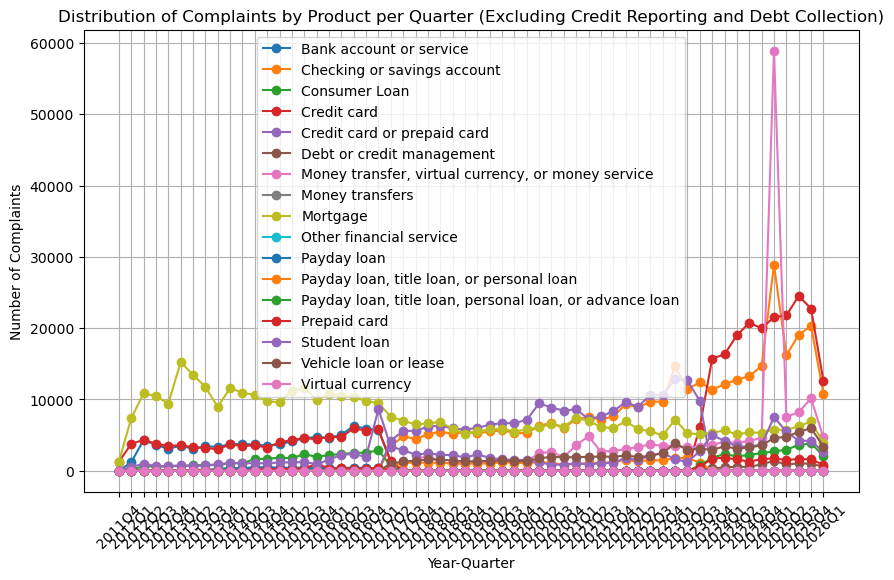

In [36]:
# Plotting the same chart but without the 3 categories starting with "credit reporting" and debt collection, as they are very dominant and make it hard to see the trends in the other products
plt.figure(figsize=(10, 6))
for product in plot_pivot.columns:
    if not product.lower().startswith('credit reporting') and not product.lower().startswith('debt collection'):
        plt.plot(x_labels, plot_pivot[product].values, marker='o', label=product)

plt.title('Distribution of Complaints by Product per Quarter (Excluding Credit Reporting and Debt Collection)')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

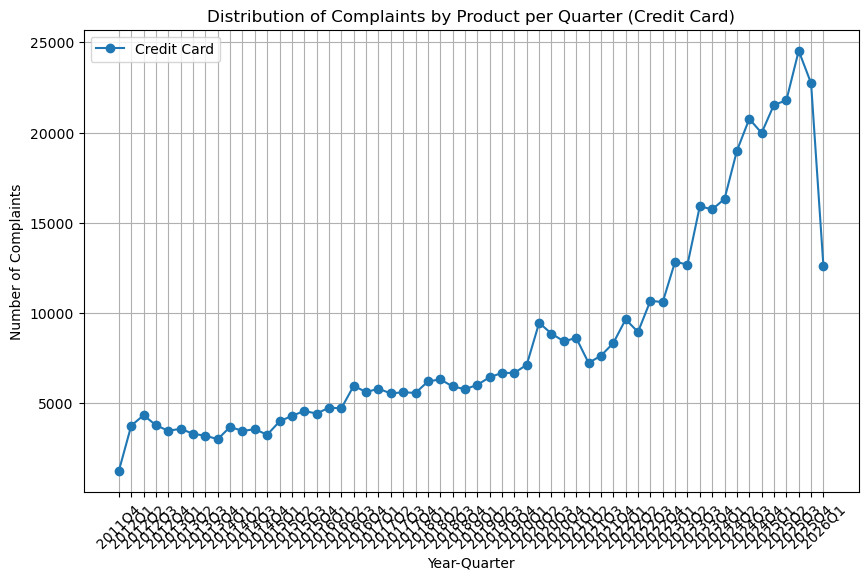

In [38]:
# Plot the same chart but only for the 2 categories starting with "credit card", combined to form one line
plt.figure(figsize=(10, 6))
credit_card_values = plot_pivot[[col for col in plot_pivot.columns if col.lower().startswith('credit card')]].sum(axis=1)
plt.plot(x_labels, credit_card_values, marker='o', label='Credit Card')

plt.title('Distribution of Complaints by Product per Quarter (Credit Card)')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Plot the above (i.e., for the 2 categories starting with "credit card", combined values) but form two lines: df['region'] == "south" region and everything else (non-South regions)
plt.figure(figsize=(10, 6))

credit_card_cols = [col for col in df['Product'].unique() if col.lower().startswith('credit card')]

for region_label in ['South', 'Non-South']:
    if region_label == 'South':
        region_df = df[df['region'] == 'South']
    else:
        region_df = df[df['region'] != 'South']

    region_counts = (
        region_df[region_df['Product'].isin(credit_card_cols)]
        .groupby('year_quarter')
        .size()
        .reset_index(name='num_complaints')
    )
    region_counts['year_q_period'] = pd.PeriodIndex(region_counts['year_quarter'], freq='Q')
    region_counts = region_counts.set_index('year_q_period').reindex(plot_pivot.index, fill_value=0)

    plt.plot(x_labels, region_counts['num_complaints'].values, marker='o', label=region_label)

plt.title('Credit Card Complaints per Quarter: South vs Non-South')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'region'

<Figure size 1000x600 with 0 Axes>

# 2. Stratified Sampling Workflow

With core time and geography features prepared, the notebook now defines strata, allocates proportional sample sizes, and validates that sampled distributions closely match the source population.

## Step 1: Dropping Missing Key Fields

For the initial state-level sampling pass, stratified sampling only works cleanly if strata are defined, so I dropped rows that had any of the specified strata info missing.

In [ ]:
df_strata = df.dropna(subset=['Product', 'year_quarter', 'geo'])

## Step 2: Creating a Strata Key

Next, I ensured that each unique Product x Year-Quarter x State combination is represented as one stratum, so that the exploratory stratified sampling works cleanly.

In [ ]:
df_strata['stratum'] = (
    df_strata['Product'].astype(str) + '|' +
    df_strata['year_quarter'].astype(str) + '|' +
    df_strata['geo'].astype(str)
)

## Step 3: Computing Stratum Sizes

In [ ]:
stratum_counts = df_strata['stratum'].value_counts()

total_rows = len(df_strata)

## Step 4: Proportional Stratified Sampling

For a target size (say 500,000): n_stratum = ( N_stratum / N_total ) x N_target

In [ ]:
import numpy as np

def stratified_sample(df, target_size, random_state=42):
    df = df.copy()
    
    # Calculate proportions
    stratum_counts = df['stratum'].value_counts()
    total = len(df)
    
    # Target sample per stratum
    stratum_sample_sizes = (
        (stratum_counts / total) * target_size
    ).round().astype(int)
    
    # Merge sizes back
    sample_map = stratum_sample_sizes.to_dict()
    df['sample_size'] = df['stratum'].map(sample_map)
    
    # Sample within each stratum
    sampled_df = (
        df.groupby('stratum', group_keys=False)
          .apply(lambda x: x.sample(
              n=min(len(x), sample_map[x.name]),
              random_state=random_state
          ))
    )
    
    return sampled_df.drop(columns=['sample_size'])


## Step 5: Generate Candidate Samples

Two sample sizes are generated for comparison:
- 500k: broader coverage for diagnostics and robustness checks
- 300k: computationally efficient size selected for the core EDA workflow

In [ ]:
# 500k sample generation
df_500k = stratified_sample(df_strata, 500_000)

# 300k sample generation
df_300k = stratified_sample(df_strata, 300_000)

## Step 6: Validate Stratification Fidelity

This step compares marginal distributions between the source population and sampled data to ensure proportional stratification behavior is preserved.

In [ ]:
def compare_distribution(original, sample, col):
    orig_dist = original[col].value_counts(normalize=True)
    sample_dist = sample[col].value_counts(normalize=True)
    return pd.concat([orig_dist, sample_dist], axis=1, keys=['original', 'sample'])

In [ ]:
compare_distribution(df_strata, df_500k, 'Product')
compare_distribution(df_strata, df_500k, 'year_quarter')
compare_distribution(df_strata, df_500k, 'geo')

## 3. Final Sample Specification

Final design decisions for downstream notebooks:
1. Stratification keys: `Product`, `year_quarter`, `region`
2. Allocation method: proportional allocation with rounding-drift correction
3. Final output size: 300,000 rows

## Step 1: Defining Strata

In [ ]:
strata_cols = ['Product', 'year_quarter', 'region']

## Step 2: Computing Proportional Allocation (Adjusting for Rounding Drift)

In [ ]:
# Target sample size
TARGET_N = 300_000

# Get stratum size
strata_counts = df.groupby(strata_cols).size().reset_index(name='count')

# Compute proportions
total_records = len(df)

strata_counts['prop'] = strata_counts['count'] / total_records
strata_counts['sample_n'] = (strata_counts['prop'] * TARGET_N).round().astype(int)

# Adjust for Rounding Drift
difference = TARGET_N - strata_counts['sample_n'].sum()

if difference != 0:
    strata_counts.loc[strata_counts.sample(difference).index, 'sample_n'] += 1


## Step 3: Merging Back & Creating Sample

In [ ]:
# Merge sample sizes into main df
df = df.merge(
    strata_counts[strata_cols + ['sample_n']],
    on=strata_cols,
    how='left'
)

In [ ]:
# Sample within each stratum
df_sample_300k = (
    df.groupby(strata_cols, group_keys=False)
      .apply(lambda x: x.sample(
          n=min(len(x), x['sample_n'].iloc[0]),
          random_state=42
      ))
)

## Step 4: Verifying Sample Size & Distribution

In [ ]:
# Verify sample size = Original target sample size
print(f"Sample size: {len(df_sample_300k):,}")

In [ ]:
# Verify distribution
df_sample_300k.groupby(strata_cols).size().describe()

# Conclusion

This notebook delivers a reproducible stratified sample that preserves key distributional structure across product, time, and geography.

- The sampling design retains representational balance while reducing computational load.
- Stratum-level diagnostics indicate acceptable sparsity and stable allocation behavior.
- The exported 300k sample is ready for notebook 02 EDA and subsequent time-series pipelines.

In [ ]:
df_sample_300k.to_parquet(
    "data/processed/cfpb_sample_300k.parquet",
    index=False
)